# Modellbewertung – Datensatz zu Herzerkrankungen

In diesem Notebook wird die Leistung des Machine-Learning-Modells anhand verschiedener Kennzahlen analysiert und bewertet.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

df = pd.read_csv("heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [2]:
df.corr()["target"].sort_values(ascending=False)

target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64

## Wichtige Merkmale

Merkmale wie die Art der Brustschmerzen (cp), die maximale Herzfrequenz (thalach) und oldpeak weisen eine starke Beziehung zur Zielvariablen auf. Diese Variablen sind daher für die Vorhersage von Herzerkrankungen besonders wichtig. Andere Merkmale wie Cholesterin oder Blutdruck zeigen schwächere Korrelationen.

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

accuracy, precision, recall

(0.7951219512195122, 0.7563025210084033, 0.8737864077669902)

## Bewertungskennzahlen

Die Genauigkeit misst die allgemeine Richtigkeit des Modells. 
Die Präzision gibt an, wie viele als positiv vorhergesagte Fälle tatsächlich korrekt sind. 
Der Recall gibt an, wie viele tatsächlich positive Fälle korrekt identifiziert wurden. 
Diese Kennzahlen ermöglichen ein besseres Verständnis der Modellleistung.

In [4]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[73, 29],
       [13, 90]])

In [5]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

sensitivity, specificity

(np.float64(0.8737864077669902), np.float64(0.7156862745098039))

## Analyse der Verwechslungsmatrix

Die Verwechslungsmatrix zeigt die Anzahl der korrekten und falschen Vorhersagen. 
Die Sensitivität (auch als Recall bezeichnet) gibt an, wie gut das Modell positive Fälle erkennt. 
Die Spezifität gibt an, wie gut das Modell negative Fälle erkennt. 
Beide Werte sind wichtig, um die Modellleistung im Detail zu bewerten.

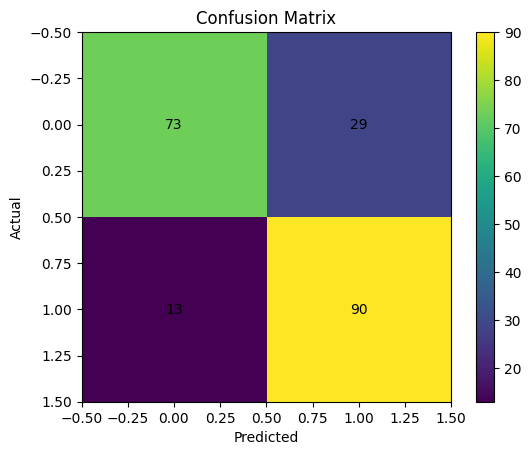

In [6]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Interpretation der Verwechslungsmatrix

Die Verwechslungsmatrix zeigt die Leistungsfähigkeit des Klassifikationsmodells. 
Sie zeigt die Anzahl der vom Modell getroffenen korrekten und falschen Vorhersagen.
Das Modell hat 73 negative Fälle (keine Herzerkrankung) und 90 positive Fälle (Herzerkrankung) korrekt vorhergesagt. 
Es gibt jedoch auch einige Fehler: 29 gesunde Patienten wurden fälschlicherweise als an einer Herzerkrankung leidend eingestuft (falsch-positive Ergebnisse), und 13 Patienten mit Herzerkrankung wurden nicht erkannt (falsch-negative Ergebnisse).
Dies deutet darauf hin, dass das Modell insgesamt gut funktioniert, insbesondere bei der Erkennung von Patienten mit Herzerkrankung, aber dennoch einige Fehler macht.

## Fazit

Das Modell liefert mit einer Genauigkeit von etwa 80 % gute Ergebnisse. 
Der Recall (ca. 0,87) zeigt, dass das Modell Patienten mit Herzerkrankungen sehr gut identifizieren kann, während die Spezifität (ca. 0,71) darauf hindeutet, dass einige gesunde Patienten falsch klassifiziert werden. 
Diese Fehler können durch Ähnlichkeiten zwischen den Patienten oder durch sich überschneidende Merkmale im Datensatz verursacht werden. 
Insgesamt ist das Modell zuverlässig, seine Leistung könnte jedoch durch den Einsatz fortschrittlicherer Algorithmen oder zusätzlicher Daten verbessert werden.